# Customer Churn Prediction — Exploration Notebook

This notebook is for **exploring and understanding** the data step by step,
one cell at a time. Run each cell with `Shift + Enter`, look at the output,
then move to the next cell. This is different from `train.py`, which runs
everything in one go for the actual final pipeline.

**Tip**: Actually read the output after every cell before moving to the next
one. That's the whole point of a notebook — pause and look.

## Step 1: Load the libraries we need

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Load the dataset and look at the first few rows

In [2]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Check data types and missing values

This is exactly what we discussed — always check this BEFORE assuming
data is clean.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# isnull() alone isn't enough - it can miss "fake" missing values
# like blank spaces that aren't technically NaN
print("Missing values reported by isnull():")
print(df.isnull().sum())

Missing values reported by isnull():
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Let's specifically check TotalCharges, since it's stored as text (object)
# instead of a number - that's suspicious
print("Data type of TotalCharges:", df["TotalCharges"].dtype)

# Try to force-convert to numbers; anything that fails becomes NaN
bad_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print(f"\nRows where TotalCharges is NOT a valid number: {len(bad_rows)}")
bad_rows[["customerID", "tenure", "TotalCharges"]]

Data type of TotalCharges: str

Rows where TotalCharges is NOT a valid number: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


## Step 4: Explore categorical columns - check for weird/unexpected values

In [6]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("customerID")

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'One year', '

/tmp/ipykernel_564/1104921022.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## Step 5: Look at the target column - how imbalanced is churn?

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


<Axes: title={'center': 'Churn distribution'}, xlabel='Churn'>

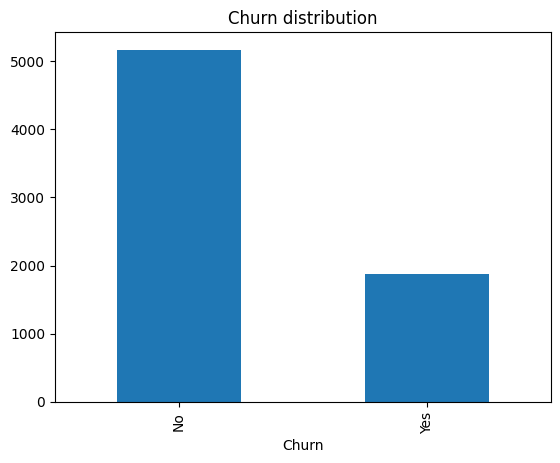

In [7]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df):.1%}")

churn_counts.plot(kind="bar", title="Churn distribution")

## Step 6: Clean the data

In [8]:
df_clean = df.drop(columns=["customerID"])
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce").fillna(0)
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

print("Cleaned! Let's confirm:")
print(df_clean[["TotalCharges", "Churn"]].dtypes)

Cleaned! Let's confirm:
TotalCharges    float64
Churn             int64
dtype: object


## Step 7: Encode categorical columns (Label Encoding)

We're turning text categories into numbers so the model can use them.

In [9]:
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Contract: {'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two 

/tmp/ipykernel_564/1326578542.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()


## Step 8: Split into train (practice) and test (exam) sets

In [10]:
feature_cols = categorical_cols + numeric_cols
X = df_clean[feature_cols]
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train)} customers")
print(f"Testing on {len(X_test)} customers (never seen during training)")
print(f"Churn rate in train: {y_train.mean():.1%}, in test: {y_test.mean():.1%} (should be similar - that's what stratify does)")

Training on 5634 customers
Testing on 1409 customers (never seen during training)
Churn rate in train: 26.5%, in test: 26.5% (should be similar - that's what stratify does)


## Step 9: Scale numeric features

In [11]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Before scaling (tenure, MonthlyCharges, TotalCharges):")
print(X_train[numeric_cols].describe().loc[["mean","std"]])
print("\nAfter scaling (should be mean~0, std~1):")
print(X_train_scaled[numeric_cols].describe().loc[["mean","std"]])

Before scaling (tenure, MonthlyCharges, TotalCharges):
         tenure  MonthlyCharges  TotalCharges  SeniorCitizen
mean  32.485091       64.929961   2299.334682       0.163294
std   24.568744       30.138105   2279.204278       0.369667

After scaling (should be mean~0, std~1):
            tenure  MonthlyCharges  TotalCharges  SeniorCitizen
mean -1.008935e-17   -2.402527e-16  2.522338e-17   7.440898e-17
std   1.000089e+00    1.000089e+00  1.000089e+00   1.000089e+00


## Step 10: Train Logistic Regression - let's see it learn

In [12]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

Logistic Regression trained!


## Step 11: Train Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained!")

Random Forest trained!


## Step 12: Evaluate both models on the HIDDEN test data

This is the moment of truth - how well did each model actually learn?

In [14]:
def evaluate(name, model):
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    print(f"--- {name} ---")
    print(f"Precision: {precision:.3f}  (of predicted churners, % actually churned)")
    print(f"Recall:    {recall:.3f}  (of actual churners, % we caught)")
    print(f"F1:        {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print(f"Confusion matrix:\n{confusion_matrix(y_test, pred)}\n")
    return f1

f1_lr = evaluate("Logistic Regression", log_reg)
f1_rf = evaluate("Random Forest", rf)

--- Logistic Regression ---
Precision: 0.505  (of predicted churners, % actually churned)
Recall:    0.797  (of actual churners, % we caught)
F1:        0.618
ROC-AUC:   0.840
Confusion matrix:
[[743 292]
 [ 76 298]]

--- Random Forest ---
Precision: 0.543  (of predicted churners, % actually churned)
Recall:    0.762  (of actual churners, % we caught)
F1:        0.634
ROC-AUC:   0.842
Confusion matrix:
[[795 240]
 [ 89 285]]



## Step 13: Which model wins, and what drives churn the most?

In [15]:
winner = "Random Forest" if f1_rf > f1_lr else "Logistic Regression"
print(f"Winner: {winner}\n")

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top churn-driving features (Random Forest):")
importance.head(10)

Winner: Random Forest

Top churn-driving features (Random Forest):


Contract            0.211741
tenure              0.138795
TotalCharges        0.114537
OnlineSecurity      0.107333
MonthlyCharges      0.102070
TechSupport         0.082498
InternetService     0.056442
PaymentMethod       0.034849
OnlineBackup        0.027557
DeviceProtection    0.024994
dtype: float64

<Axes: title={'center': 'Top churn-driving features'}>

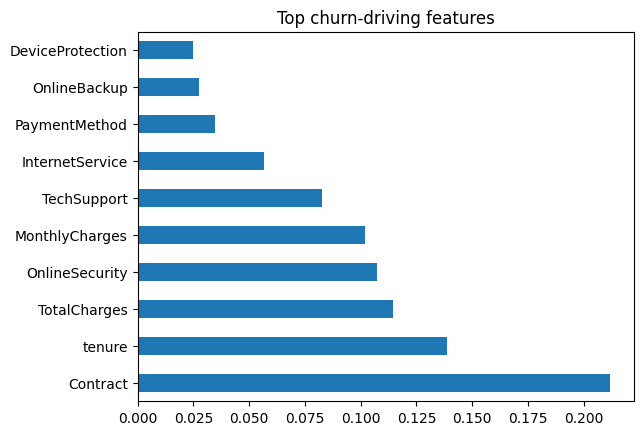

In [16]:
importance.head(10).plot(kind="barh", title="Top churn-driving features")

## Step 14: (Bonus) Try One-Hot Encoding instead - does it change things?

This answers the question: "would one-hot encoding give better results?"
Try running this and comparing the F1 scores to Step 12.

In [17]:
df_onehot = pd.get_dummies(df_clean.copy(), columns=[c for c in df.columns if df[c].dtype == "object" and c != "customerID"], drop_first=True)
# Note: run this on a fresh copy of df if you want to compare properly
print(f"Label encoding used {len(feature_cols)} columns")
print(f"One-hot encoding would use {df_onehot.shape[1] - 1} columns")
print("\nTry retraining with df_onehot and compare F1 scores to see the real difference on THIS dataset!")

Label encoding used 19 columns
One-hot encoding would use 19 columns

Try retraining with df_onehot and compare F1 scores to see the real difference on THIS dataset!


## Next steps

Once you're comfortable with every cell above, the **final, clean version**
of this logic lives in `train.py` — a single script version meant to be run
automatically (e.g., by a scheduled retraining job or by the setup process
for our API). Notebooks are for learning/exploring; scripts are for
production. Both are valuable, for different purposes.